# Movie Rating Prediction with python

Import libraries

In [94]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

Load Dataset

In [95]:
data = pd.read_csv("C:/Users/khana/OneDrive/Desktop/Movie_Rating_pred/IMDb Movies India.csv", encoding='latin1')
data.head(5)

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


EDA process

In [96]:
data.shape

(15509, 10)

In [97]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  str    
 1   Year      14981 non-null  str    
 2   Duration  7240 non-null   str    
 3   Genre     13632 non-null  str    
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   str    
 6   Director  14984 non-null  str    
 7   Actor 1   13892 non-null  str    
 8   Actor 2   13125 non-null  str    
 9   Actor 3   12365 non-null  str    
dtypes: float64(1), str(9)
memory usage: 2.3 MB


Before removing missing vaues

In [98]:
data.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [99]:
data.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


Data Cleaning

In [100]:
data['Year'] = data['Year'].fillna(data['Year'].mode()[0])

Remove the text in column Duration 

In [101]:
data['Duration'] = data['Duration'].str.replace('min', ' ')
data['Duration'] = pd.to_numeric(data['Duration'], errors = 'coerce')

In [102]:
data['Duration'] = data['Duration'].fillna(data['Duration'].median())

In [103]:
data['Genre'] = data['Genre'].fillna('Unknown')

In [104]:
data['Rating'] = data['Rating'].fillna(data['Rating'].median())

replace string to numeric

In [105]:
data['Votes'] = data['Votes'].str.replace(',', '')
data['Votes'] = pd.to_numeric(data['Votes'], errors = 'coerce')

In [106]:
data['Votes'] = data['Votes'].fillna(data['Votes'].mean())

In [107]:
data['Director'] = data['Director'].fillna('Unknown')

In [108]:
data['Actor 1'] = data['Actor 1'].fillna('Unknown')
data['Actor 2'] = data['Actor 2'].fillna('Unknown')
data['Actor 3'] = data['Actor 3'].fillna('Unknown')

after removing missing values

In [109]:
data.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

Check duplicate 

In [110]:
data.duplicated().sum()

np.int64(6)

Remove duplicate row

In [111]:
data = data.drop_duplicates()

Check duplicate after removing

In [112]:
data.duplicated().sum()

np.int64(0)

Identify target column

In [113]:
data.columns

Index(['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director',
       'Actor 1', 'Actor 2', 'Actor 3'],
      dtype='str')

In [114]:
data.info()

<class 'pandas.DataFrame'>
Index: 15503 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15503 non-null  str    
 1   Year      15503 non-null  str    
 2   Duration  15503 non-null  float64
 3   Genre     15503 non-null  str    
 4   Rating    15503 non-null  float64
 5   Votes     15503 non-null  float64
 6   Director  15503 non-null  str    
 7   Actor 1   15503 non-null  str    
 8   Actor 2   15503 non-null  str    
 9   Actor 3   15503 non-null  str    
dtypes: float64(3), str(7)
memory usage: 2.4 MB


Numerical columns[Duration, Rating, Votes]
Categorical columns[Name,Year,Genre,Director,Actor 1,Actor 2,Actor 3]

ENCODING

In [115]:
L = LabelEncoder()
for col in ['Name', 'Year', 'Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    data[col] = L.fit_transform(data[col])

Separate Feature(x) and Target(y)

In [116]:
x = data[['Name', 'Year', 'Genre', 'Duration', 'Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Votes']]
y = data['Rating']
print(x.head(5))
print(y.head(5))

   Name  Year  Genre  Duration  Director  Actor 1  Actor 2  Actor 3  \
0     0    98    299     131.0      1926     2250      800     3108   
1     1    98    299     109.0      1548     3280     4791      527   
2     2   100    351      90.0      5123     3713     2866     3450   
3     3    98    228     110.0      3319     2917     1504     4020   
4     7    89    299     105.0       385     3112     3462      405   

         Votes  
0  1938.520394  
1     8.000000  
2  1938.520394  
3    35.000000  
4  1938.520394  
0    6.0
1    7.0
2    6.0
3    4.4
4    6.0
Name: Rating, dtype: float64


Train-Test split

In [117]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state =42)

Model train

In [118]:
from sklearn.ensemble import RandomForestRegressor
R = RandomForestRegressor(n_estimators=100,random_state=42)

In [119]:

R.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

Prediction

In [120]:
y_pred = R.predict(x_test)

In [121]:
print(y_pred[:5])

[6.604 5.045 6.866 6.    6.   ]


Evualtion

In [122]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE:", mse)
print("R2:", r2)

MSE: 0.6567351470493389
R2: 0.32822723207215176


Actual_rating VS Pred_rating

In [123]:
comp = pd.DataFrame({'Actual':y_test, 'Predicted':y_pred})
comp.head(10)

,Actual,Predicted
11935,6.1,6.604
11402,3.6,5.045
4924,5.8,6.866
15257,6.0,6.000
6708,6.0,6.000
7190,6.0,5.926
10872,6.7,6.631
3100,6.0,6.000
3316,7.2,6.744
7767,4.2,5.221


Visualization

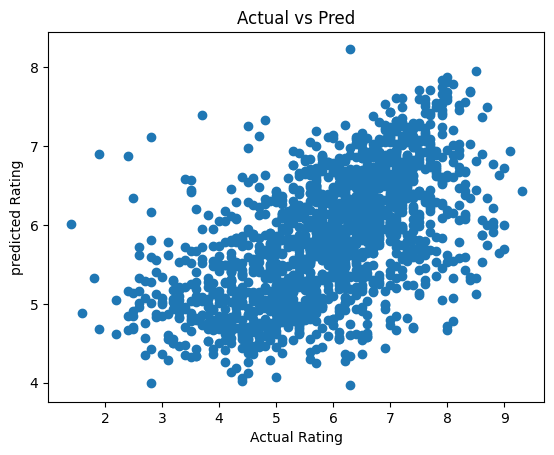

In [124]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Rating")
plt.ylabel("predicted Rating")
plt.title("Actual vs Pred")
plt.show()

R2 score comparison graph 

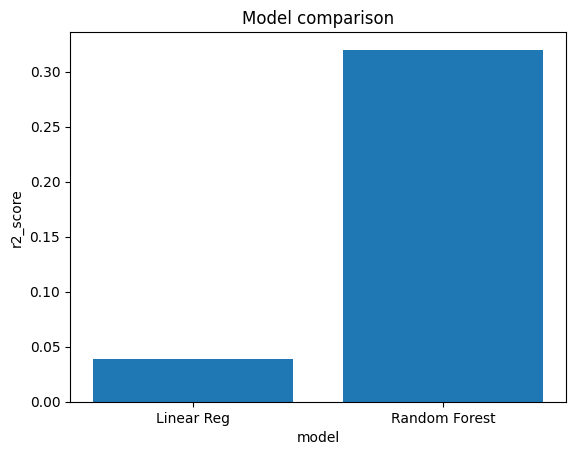

In [125]:
model = ['Linear Reg', 'Random Forest']
r2_score = [0.039, 0.32]
plt.bar(model, r2_score)
plt.title("Model comparison")
plt.xlabel('model')
plt.ylabel('r2_score')
plt.show()